# Evaluation Session Analysis: eval_session_20250902_212844

This notebook analyzes the evaluation results from the training session, providing:
1. Average cumulative reward over all episodes and caves with standard deviation
2. Average cumulative reward per cave over all episodes with standard deviation

In [186]:
eval_session_path = "/home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539"

In [187]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

latex_linewidth_pt = 483.6969
pt_to_inch = 1/72.27
latex_linewidth_in = latex_linewidth_pt * pt_to_inch

In [188]:
# Load the evaluation session data
session_summary_path = os.path.join(eval_session_path, "session_summary.json")

print(f"Loading data from: {eval_session_path}")

# Load session summary
with open(session_summary_path, 'r') as f:
    session_data = json.load(f)

print(f"Evaluation timestamp: {session_data['eval_timestamp']}")
print(f"Episodes per cave: {session_data['episodes_per_cave']}")
print(f"Number of caves: {len(session_data['caves'])}")
print(f"Caves directory: {session_data['caves_directory']}")
print(f"Max steps per episode: {session_data['max_steps']}")

Loading data from: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539
Evaluation timestamp: 20250911_145539
Episodes per cave: 3
Number of caves: 30
Caves directory: new_caves/long_caves
Max steps per episode: 7500


In [189]:
# Extract all reward data
all_rewards = []
cave_rewards = {}

for cave_data in session_data['caves']:
    cave_id = cave_data['cave_id']
    cave_rewards[cave_id] = []
    
    for episode in cave_data['episodes']:
        reward = episode['final_cumulative_reward']
        all_rewards.append(reward)
        cave_rewards[cave_id].append(reward)

print(f"Total episodes analyzed: {len(all_rewards)}")
print(f"Caves analyzed: {sorted(cave_rewards.keys())}")
print(f"First few rewards: {all_rewards[:10]}")
print(f"Reward range: [{min(all_rewards):.2f}, {max(all_rewards):.2f}]")

Total episodes analyzed: 90
Caves analyzed: [271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300]
First few rewards: [28.643300036776964, 15.202851466153447, 35.15485260457899, 34.733063060477434, 15.968024347378048, 109.48055862094634, 46.988456647826595, 38.45794838136737, 47.20728014097398, 13.640511206700467]
Reward range: [-37.62, 109.48]


In [190]:
# Calculate overall statistics (all episodes across all caves)
overall_mean = np.mean(all_rewards)
overall_std = np.std(all_rewards)

print("="*60)
print("OVERALL STATISTICS (All Episodes Across All Caves)")
print("="*60)
print(f"Average cumulative reward: {overall_mean:.4f}")
print(f"Standard deviation:        {overall_std:.4f}")
print(f"Number of episodes:        {len(all_rewards)}")
print(f"Number of caves:           {len(cave_rewards)}")
print("="*60)

OVERALL STATISTICS (All Episodes Across All Caves)
Average cumulative reward: 39.5891
Standard deviation:        28.1671
Number of episodes:        90
Number of caves:           30


In [191]:
# Calculate per-cave statistics
cave_stats = {}
cave_means = []
cave_stds = []

print("\nPER-CAVE STATISTICS (Average over all episodes per cave)")
print("="*80)
print(f"{'Cave ID':<8} {'Mean Reward':<12} {'Std Dev':<12} {'Episodes':<10} {'Min':<10} {'Max':<10}")
print("-"*80)

for cave_id in sorted(cave_rewards.keys()):
    rewards = cave_rewards[cave_id]
    cave_mean = np.mean(rewards)
    cave_std = np.std(rewards)
    cave_min = np.min(rewards)
    cave_max = np.max(rewards)
    
    cave_stats[cave_id] = {
        'mean': cave_mean,
        'std': cave_std,
        'min': cave_min,
        'max': cave_max,
        'count': len(rewards)
    }
    
    cave_means.append(cave_mean)
    cave_stds.append(cave_std)
    
    print(f"{cave_id:<8} {cave_mean:<12.4f} {cave_std:<12.4f} {len(rewards):<10} {cave_min:<10.4f} {cave_max:<10.4f}")

print("-"*80)


PER-CAVE STATISTICS (Average over all episodes per cave)
Cave ID  Mean Reward  Std Dev      Episodes   Min        Max       
--------------------------------------------------------------------------------
271      26.3337      8.3075       3          15.2029    35.1549   
272      53.3939      40.3924      3          15.9680    109.4806  
273      44.2179      4.0739       3          38.4579    47.2073   
274      40.8343      40.1227      3          11.3020    97.5603   
275      48.3649      10.5484      3          37.6147    62.6969   
276      36.3382      21.6384      3          5.7394     51.9740   
277      31.1450      4.3181       3          25.6380    36.1839   
278      22.5323      5.5253       3          16.0039    29.5152   
279      53.4817      30.9443      3          9.9602     79.2090   
280      10.7280      23.3133      3          -14.9381   41.4833   
281      60.8937      30.5907      3          29.5894    102.4053  
282      22.8916      12.7615      3         

In [192]:
# Summary statistics across caves
print("\nSUMMARY STATISTICS ACROSS CAVES")
print("="*50)
print(f"Mean of cave means:         {np.mean(cave_means):.4f}")
print(f"Std of cave means:          {np.std(cave_means):.4f}")
print(f"Mean of cave std devs:      {np.mean(cave_stds):.4f}")
print(f"Best performing cave:       Cave {sorted(cave_rewards.keys())[np.argmax(cave_means)]} (mean: {np.max(cave_means):.4f})")
print(f"Worst performing cave:      Cave {sorted(cave_rewards.keys())[np.argmin(cave_means)]} (mean: {np.min(cave_means):.4f})")
print("="*50)


SUMMARY STATISTICS ACROSS CAVES
Mean of cave means:         39.5891
Std of cave means:          16.1417
Mean of cave std devs:      20.0699
Best performing cave:       Cave 284 (mean: 76.5914)
Worst performing cave:      Cave 280 (mean: 10.7280)


/tmp/ipykernel_1412246/2411670488.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(first_15_rewards, labels=first_15_caves)


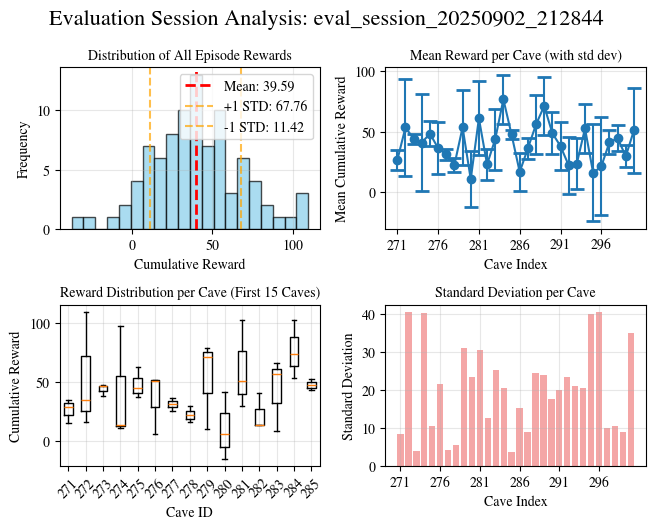

In [193]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(latex_linewidth_in, 0.8 * latex_linewidth_in))
fig.suptitle('Evaluation Session Analysis: eval_session_20250902_212844', fontsize=16)

# Plot 1: Distribution of all rewards
axes[0, 0].hist(all_rewards, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
axes[0, 0].axvline(overall_mean + overall_std, color='orange', linestyle='--', alpha=0.7, label=f'+1 STD: {overall_mean + overall_std:.2f}')
axes[0, 0].axvline(overall_mean - overall_std, color='orange', linestyle='--', alpha=0.7, label=f'-1 STD: {overall_mean - overall_std:.2f}')
axes[0, 0].set_title('Distribution of All Episode Rewards')
axes[0, 0].set_xlabel('Cumulative Reward')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Cave mean rewards
cave_ids = sorted(cave_rewards.keys())
means = [cave_stats[cave_id]['mean'] for cave_id in cave_ids]
stds = [cave_stats[cave_id]['std'] for cave_id in cave_ids]

axes[0, 1].errorbar(range(len(cave_ids)), means, yerr=stds, fmt='o-', capsize=5, capthick=2)
axes[0, 1].set_title('Mean Reward per Cave (with std dev)')
axes[0, 1].set_xlabel('Cave Index')
axes[0, 1].set_ylabel('Mean Cumulative Reward')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, len(cave_ids), 5))
axes[0, 1].set_xticklabels([str(cave_ids[i]) for i in range(0, len(cave_ids), 5)])

# Plot 3: Box plot of rewards per cave (showing first 15 caves for readability)
first_15_caves = cave_ids[:15]
first_15_rewards = [cave_rewards[cave_id] for cave_id in first_15_caves]
axes[1, 0].boxplot(first_15_rewards, labels=first_15_caves)
axes[1, 0].set_title('Reward Distribution per Cave (First 15 Caves)')
axes[1, 0].set_xlabel('Cave ID')
axes[1, 0].set_ylabel('Cumulative Reward')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Standard deviation per cave
axes[1, 1].bar(range(len(cave_ids)), stds, alpha=0.7, color='lightcoral')
axes[1, 1].set_title('Standard Deviation per Cave')
axes[1, 1].set_xlabel('Cave Index')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(0, len(cave_ids), 5))
axes[1, 1].set_xticklabels([str(cave_ids[i]) for i in range(0, len(cave_ids), 5)])

plt.tight_layout()
plt.show()

In [194]:
# Create a summary DataFrame
summary_data = []
for cave_id in sorted(cave_rewards.keys()):
    stats = cave_stats[cave_id]
    summary_data.append({
        'Cave_ID': cave_id,
        'Mean_Reward': stats['mean'],
        'Std_Reward': stats['std'],
        'Min_Reward': stats['min'],
        'Max_Reward': stats['max'],
        'Num_Episodes': stats['count']
    })

df_summary = pd.DataFrame(summary_data)

print("CAVE PERFORMANCE SUMMARY TABLE")
print("="*70)
print(df_summary.round(4).to_string(index=False))

# Save summary to CSV
output_path = "/home/ga53voq/master_thesis/tools/eval_session_20250902_212844_analysis.csv"
df_summary.to_csv(output_path, index=False)
print(f"\nSummary saved to: {output_path}")

CAVE PERFORMANCE SUMMARY TABLE
 Cave_ID  Mean_Reward  Std_Reward  Min_Reward  Max_Reward  Num_Episodes
     271      26.3337      8.3075     15.2029     35.1549             3
     272      53.3939     40.3924     15.9680    109.4806             3
     273      44.2179      4.0739     38.4579     47.2073             3
     274      40.8343     40.1227     11.3020     97.5603             3
     275      48.3649     10.5484     37.6147     62.6969             3
     276      36.3382     21.6384      5.7394     51.9740             3
     277      31.1450      4.3181     25.6380     36.1839             3
     278      22.5323      5.5253     16.0039     29.5152             3
     279      53.4817     30.9443      9.9602     79.2090             3
     280      10.7280     23.3133    -14.9381     41.4833             3
     281      60.8937     30.5907     29.5894    102.4053             3
     282      22.8916     12.7615     13.7484     40.9386             3
     283      43.7454     25.2120

In [195]:
# Final Summary
print("\n" + "="*80)
print("FINAL ANALYSIS SUMMARY")
print("="*80)
print(f"Evaluation Session: {eval_session_path.split('/')[-1]}")
print(f"Date: {session_data['start_time']}")
print(f"Caves Directory: {session_data['caves_directory']}")
print()
print("KEY FINDINGS:")
print(f"• Total Episodes Analyzed: {len(all_rewards)}")
print(f"• Total Caves Analyzed: {len(cave_rewards)}")
print(f"• Episodes per Cave: {session_data['episodes_per_cave']}")
print()
print("OVERALL PERFORMANCE (All Episodes Across All Caves):")
print(f"• Average Cumulative Reward: {overall_mean:.4f} ± {overall_std:.4f}")
print()
print("PER-CAVE PERFORMANCE:")
print(f"• Mean of Cave Averages: {np.mean(cave_means):.4f}")
print(f"• Std of Cave Averages: {np.std(cave_means):.4f}")
print(f"• Best Cave Performance: Cave {sorted(cave_rewards.keys())[np.argmax(cave_means)]} (avg: {np.max(cave_means):.4f})")
print(f"• Worst Cave Performance: Cave {sorted(cave_rewards.keys())[np.argmin(cave_means)]} (avg: {np.min(cave_means):.4f})")
print("="*80)


FINAL ANALYSIS SUMMARY
Evaluation Session: C6_eval_session_20250911_145539
Date: 2025-09-11T14:51:03.715140
Caves Directory: new_caves/long_caves

KEY FINDINGS:
• Total Episodes Analyzed: 90
• Total Caves Analyzed: 30
• Episodes per Cave: 3

OVERALL PERFORMANCE (All Episodes Across All Caves):
• Average Cumulative Reward: 39.5891 ± 28.1671

PER-CAVE PERFORMANCE:
• Mean of Cave Averages: 39.5891
• Std of Cave Averages: 16.1417
• Best Cave Performance: Cave 284 (avg: 76.5914)
• Worst Cave Performance: Cave 280 (avg: 10.7280)


In [196]:
# Analyze episodes stopped early (steps < max_steps)
max_steps_limit = session_data['max_steps']  # Should be 7500
early_stopped_episodes = []
total_episodes = 0
cave_early_stops = {}

print("="*60)
print("EARLY STOPPING ANALYSIS")
print("="*60)
print(f"Max steps limit: {max_steps_limit}")
print()

for cave_data in session_data['caves']:
    cave_id = cave_data['cave_id']
    cave_early_stops[cave_id] = 0
    
    for episode in cave_data['episodes']:
        total_episodes += 1
        steps = episode['steps']
        
        if steps < max_steps_limit:
            early_stopped_episodes.append({
                'cave_id': cave_id,
                'episode_index': episode['episode_index'],
                'steps': steps,
                'reward': episode['final_cumulative_reward']
            })
            cave_early_stops[cave_id] += 1

num_early_stopped = len(early_stopped_episodes)
early_stop_percentage = (num_early_stopped / total_episodes) * 100

print(f"Total episodes: {total_episodes}")
print(f"Episodes stopped early: {num_early_stopped}")
print(f"Early stopping percentage: {early_stop_percentage:.2f}%")
print(f"Episodes that completed full duration: {total_episodes - num_early_stopped}")
print()

if num_early_stopped > 0:
    early_steps = [ep['steps'] for ep in early_stopped_episodes]
    print(f"Average steps in early-stopped episodes: {np.mean(early_steps):.2f}")
    print(f"Min steps in early-stopped episodes: {min(early_steps)}")
    print(f"Max steps in early-stopped episodes: {max(early_steps)}")
    
    early_rewards = [ep['reward'] for ep in early_stopped_episodes]
    print(f"Average reward in early-stopped episodes: {np.mean(early_rewards):.4f}")
    print()
    
    print("Early stops per cave:")
    print("-" * 40)
    for cave_id in sorted(cave_early_stops.keys()):
        episodes_in_cave = len([ep for ep in session_data['caves'] if ep['cave_id'] == cave_id][0]['episodes'])
        early_stops = cave_early_stops[cave_id]
        cave_early_percentage = (early_stops / episodes_in_cave) * 100 if episodes_in_cave > 0 else 0
        print(f"Cave {cave_id}: {early_stops}/{episodes_in_cave} episodes ({cave_early_percentage:.1f}%)")
else:
    print("No episodes were stopped early - all episodes completed the full duration.")

print("="*60)

EARLY STOPPING ANALYSIS
Max steps limit: 7500

Total episodes: 90
Episodes stopped early: 49
Early stopping percentage: 54.44%
Episodes that completed full duration: 41

Average steps in early-stopped episodes: 4000.39
Min steps in early-stopped episodes: 422
Max steps in early-stopped episodes: 7306
Average reward in early-stopped episodes: 44.0959

Early stops per cave:
----------------------------------------
Cave 271: 3/3 episodes (100.0%)
Cave 272: 1/3 episodes (33.3%)
Cave 273: 0/3 episodes (0.0%)
Cave 274: 2/3 episodes (66.7%)
Cave 275: 1/3 episodes (33.3%)
Cave 276: 3/3 episodes (100.0%)
Cave 277: 3/3 episodes (100.0%)
Cave 278: 2/3 episodes (66.7%)
Cave 279: 2/3 episodes (66.7%)
Cave 280: 1/3 episodes (33.3%)
Cave 281: 1/3 episodes (33.3%)
Cave 282: 3/3 episodes (100.0%)
Cave 283: 2/3 episodes (66.7%)
Cave 284: 1/3 episodes (33.3%)
Cave 285: 2/3 episodes (66.7%)
Cave 286: 2/3 episodes (66.7%)
Cave 287: 3/3 episodes (100.0%)
Cave 288: 0/3 episodes (0.0%)
Cave 289: 3/3 episodes 

In [197]:
# Analyze maximum x-position and energy usage in each episode
print("="*60)
print("MAXIMUM X-POSITION, ENERGY USAGE, MISSION SUCCESS, AND BOOM ANALYSIS")
print("="*60)

all_max_x_positions = []
cave_max_x_positions = {}
all_energy_usage = []
cave_energy_usage = {}
all_mission_success = []
cave_mission_success = {}
all_boom_stickiness_steps = []
cave_boom_stickiness_steps = {}
all_boom_network_steps = []
cave_boom_network_steps = {}
all_total_steps = []  # Track total steps for percentage calculation
cave_total_steps = {}

for cave_data in session_data['caves']:
    cave_id = cave_data['cave_id']
    cave_max_x_positions[cave_id] = []
    cave_energy_usage[cave_id] = []
    cave_mission_success[cave_id] = []
    cave_boom_stickiness_steps[cave_id] = []
    cave_boom_network_steps[cave_id] = []
    cave_total_steps[cave_id] = []
    
    print(f"Processing Cave {cave_id}...")
    
    for episode in cave_data['episodes']:
        episode_file = os.path.join(eval_session_path, cave_data['dir'], episode['log_file'])
        
        # Load episode data
        with open(episode_file, 'r') as f:
            episode_data = json.load(f)
        
        # Find maximum x-position, last energy usage, mission success, and boom tracking during the episode
        max_x_pos = 0.0  # Initialize to 0
        last_energy_usage = 0.0  # Initialize to 0
        mission_success = False  # Initialize to False
        boom_stickiness_active_steps = 0  # Count steps where at least one boom is sticky
        boom_network_active_steps = 0  # Count steps where at least one boom is activated by network
        total_steps_in_episode = 0  # Count total steps in this episode
        
        for step_data in episode_data['steps']:
            total_steps_in_episode += 1  # Count each step
            
            if 'info' in step_data:
                # Track max x-position
                if 'max_x_position' in step_data['info']:
                    x_pos = step_data['info']['max_x_position']
                    if x_pos > max_x_pos:
                        max_x_pos = x_pos
                
                # Track energy usage (keep last value)
                if 'energy_usage' in step_data['info']:
                    last_energy_usage = step_data['info']['energy_usage']
                
                # Track boom stickiness active
                if 'boom_stickiness_active' in step_data['info']:
                    boom_stickiness = step_data['info']['boom_stickiness_active']
                    if isinstance(boom_stickiness, list) and any(boom_stickiness):
                        boom_stickiness_active_steps += 1
                
                # Track boom activated by network
                if 'boom_activated_by_network' in step_data['info']:
                    boom_network = step_data['info']['boom_activated_by_network']
                    if isinstance(boom_network, list) and any(boom_network):
                        boom_network_active_steps += 1
                
                # Track mission success (if it ever becomes True, keep it True)
                if 'mission_success' in step_data['metrics']:
                    if step_data['metrics']['mission_success'] > 0:
                        mission_success = True
        
        all_max_x_positions.append(max_x_pos)
        cave_max_x_positions[cave_id].append(max_x_pos)
        all_energy_usage.append(last_energy_usage)
        cave_energy_usage[cave_id].append(last_energy_usage)
        all_mission_success.append(mission_success)
        cave_mission_success[cave_id].append(mission_success)
        all_boom_stickiness_steps.append(boom_stickiness_active_steps)
        cave_boom_stickiness_steps[cave_id].append(boom_stickiness_active_steps)
        all_boom_network_steps.append(boom_network_active_steps)
        cave_boom_network_steps[cave_id].append(boom_network_active_steps)
        all_total_steps.append(total_steps_in_episode)
        cave_total_steps[cave_id].append(total_steps_in_episode)

print(f"Processed {len(all_max_x_positions)} episodes across {len(cave_max_x_positions)} caves")
print()

# Calculate overall statistics for max x-position
overall_max_x_mean = np.mean(all_max_x_positions)
overall_max_x_std = np.std(all_max_x_positions)

print("OVERALL MAX X-POSITION STATISTICS (All Episodes Across All Caves)")
print("-" * 60)
print(f"Average max x-position:    {overall_max_x_mean:.6f}")
print(f"Standard deviation:        {overall_max_x_std:.6f}")
print(f"Minimum max x-position:    {min(all_max_x_positions):.6f}")
print(f"Maximum max x-position:    {max(all_max_x_positions):.6f}")
print(f"Number of episodes:        {len(all_max_x_positions)}")
print()

# Calculate overall statistics for energy usage
overall_energy_mean = np.mean(all_energy_usage)
overall_energy_std = np.std(all_energy_usage)

print("OVERALL ENERGY USAGE STATISTICS (All Episodes Across All Caves)")
print("-" * 60)
print(f"Average energy usage:      {overall_energy_mean:.6f}")
print(f"Standard deviation:        {overall_energy_std:.6f}")
print(f"Minimum energy usage:      {min(all_energy_usage):.6f}")
print(f"Maximum energy usage:      {max(all_energy_usage):.6f}")
print(f"Number of episodes:        {len(all_energy_usage)}")
print()

# Calculate overall statistics for mission success
total_mission_success = sum(all_mission_success)
mission_success_percentage = (total_mission_success / len(all_mission_success)) * 100

print("OVERALL MISSION SUCCESS STATISTICS (All Episodes Across All Caves)")
print("-" * 60)
print(f"Total episodes with mission success: {total_mission_success}")
print(f"Total episodes:                      {len(all_mission_success)}")
print(f"Mission success rate:                {mission_success_percentage:.2f}%")
print()

# Calculate overall statistics for boom stickiness
overall_boom_stickiness_mean = np.mean(all_boom_stickiness_steps)
overall_boom_stickiness_std = np.std(all_boom_stickiness_steps)
total_boom_stickiness_steps = sum(all_boom_stickiness_steps)
total_steps_all_episodes = sum(all_total_steps)
boom_stickiness_percentage = (total_boom_stickiness_steps / total_steps_all_episodes) * 100 if total_steps_all_episodes > 0 else 0

print("OVERALL BOOM STICKINESS ACTIVE STATISTICS (All Episodes Across All Caves)")
print("-" * 60)
print(f"Average steps with boom stickiness active: {overall_boom_stickiness_mean:.2f}")
print(f"Standard deviation:                        {overall_boom_stickiness_std:.2f}")
print(f"Minimum steps with boom stickiness:       {min(all_boom_stickiness_steps)}")
print(f"Maximum steps with boom stickiness:       {max(all_boom_stickiness_steps)}")
print(f"Total steps with boom stickiness active:  {total_boom_stickiness_steps}")
print(f"Total steps across all episodes:          {total_steps_all_episodes}")
print(f"Percentage of steps with boom stickiness: {boom_stickiness_percentage:.2f}%")
print(f"Number of episodes:                        {len(all_boom_stickiness_steps)}")
print()

# Calculate overall statistics for boom activated by network
overall_boom_network_mean = np.mean(all_boom_network_steps)
overall_boom_network_std = np.std(all_boom_network_steps)
total_boom_network_steps = sum(all_boom_network_steps)
boom_network_percentage = (total_boom_network_steps / total_steps_all_episodes) * 100 if total_steps_all_episodes > 0 else 0

print("OVERALL BOOM ACTIVATED BY NETWORK STATISTICS (All Episodes Across All Caves)")
print("-" * 60)
print(f"Average steps with boom network activation: {overall_boom_network_mean:.2f}")
print(f"Standard deviation:                         {overall_boom_network_std:.2f}")
print(f"Minimum steps with boom network:           {min(all_boom_network_steps)}")
print(f"Maximum steps with boom network:           {max(all_boom_network_steps)}")
print(f"Total steps with boom network activation:  {total_boom_network_steps}")
print(f"Total steps across all episodes:           {total_steps_all_episodes}")
print(f"Percentage of steps with boom network activation: {boom_network_percentage:.2f}%")
print(f"Number of episodes:                         {len(all_boom_network_steps)}")
print()

# Calculate per-cave statistics for max x-position
cave_max_x_stats = {}
cave_max_x_means = []

print("PER-CAVE MAX X-POSITION STATISTICS")
print("-" * 80)
print(f"{'Cave ID':<8} {'Mean Max X':<12} {'Std Dev':<12} {'Episodes':<10} {'Min':<12} {'Max':<12}")
print("-" * 80)

for cave_id in sorted(cave_max_x_positions.keys()):
    max_x_values = cave_max_x_positions[cave_id]
    cave_mean_max_x = np.mean(max_x_values)
    cave_std_max_x = np.std(max_x_values)
    cave_min_max_x = np.min(max_x_values)
    cave_max_max_x = np.max(max_x_values)
    
    cave_max_x_stats[cave_id] = {
        'mean': cave_mean_max_x,
        'std': cave_std_max_x,
        'min': cave_min_max_x,
        'max': cave_max_max_x,
        'count': len(max_x_values)
    }
    
    cave_max_x_means.append(cave_mean_max_x)
    
    print(f"{cave_id:<8} {cave_mean_max_x:<12.6f} {cave_std_max_x:<12.6f} {len(max_x_values):<10} {cave_min_max_x:<12.6f} {cave_max_max_x:<12.6f}")

print("-" * 80)
print()

# Calculate per-cave statistics for energy usage
cave_energy_stats = {}
cave_energy_means = []

print("PER-CAVE ENERGY USAGE STATISTICS")
print("-" * 80)
print(f"{'Cave ID':<8} {'Mean Energy':<12} {'Std Dev':<12} {'Episodes':<10} {'Min':<12} {'Max':<12}")
print("-" * 80)

for cave_id in sorted(cave_energy_usage.keys()):
    energy_values = cave_energy_usage[cave_id]
    cave_mean_energy = np.mean(energy_values)
    cave_std_energy = np.std(energy_values)
    cave_min_energy = np.min(energy_values)
    cave_max_energy = np.max(energy_values)
    
    cave_energy_stats[cave_id] = {
        'mean': cave_mean_energy,
        'std': cave_std_energy,
        'min': cave_min_energy,
        'max': cave_max_energy,
        'count': len(energy_values)
    }
    
    cave_energy_means.append(cave_mean_energy)
    
    print(f"{cave_id:<8} {cave_mean_energy:<12.6f} {cave_std_energy:<12.6f} {len(energy_values):<10} {cave_min_energy:<12.6f} {cave_max_energy:<12.6f}")

print("-" * 80)
print()

# Calculate per-cave statistics for mission success
cave_mission_success_stats = {}
cave_mission_success_rates = []

print("PER-CAVE MISSION SUCCESS STATISTICS")
print("-" * 70)
print(f"{'Cave ID':<8} {'Success Count':<14} {'Total Episodes':<15} {'Success Rate %':<15}")
print("-" * 70)

for cave_id in sorted(cave_mission_success.keys()):
    success_values = cave_mission_success[cave_id]
    cave_success_count = sum(success_values)
    cave_total_episodes = len(success_values)
    cave_success_rate = (cave_success_count / cave_total_episodes) * 100 if cave_total_episodes > 0 else 0
    
    cave_mission_success_stats[cave_id] = {
        'success_count': cave_success_count,
        'total_episodes': cave_total_episodes,
        'success_rate': cave_success_rate
    }
    
    cave_mission_success_rates.append(cave_success_rate)
    
    print(f"{cave_id:<8} {cave_success_count:<14} {cave_total_episodes:<15} {cave_success_rate:<15.2f}")

print("-" * 70)
print()

# Calculate per-cave statistics for boom stickiness with percentages
cave_boom_stickiness_stats = {}
cave_boom_stickiness_means = []
cave_boom_stickiness_percentages = []

print("PER-CAVE BOOM STICKINESS ACTIVE STATISTICS")
print("-" * 95)
print(f"{'Cave ID':<8} {'Mean Steps':<12} {'Std Dev':<12} {'Episodes':<10} {'Min':<8} {'Max':<8} {'% of Steps':<12}")
print("-" * 95)

for cave_id in sorted(cave_boom_stickiness_steps.keys()):
    stickiness_values = cave_boom_stickiness_steps[cave_id]
    cave_mean_stickiness = np.mean(stickiness_values)
    cave_std_stickiness = np.std(stickiness_values)
    cave_min_stickiness = np.min(stickiness_values)
    cave_max_stickiness = np.max(stickiness_values)
    
    # Calculate percentage for this cave
    cave_total_stickiness_steps = sum(stickiness_values)
    cave_total_steps_sum = sum(cave_total_steps[cave_id])
    cave_stickiness_percentage = (cave_total_stickiness_steps / cave_total_steps_sum) * 100 if cave_total_steps_sum > 0 else 0
    
    cave_boom_stickiness_stats[cave_id] = {
        'mean': cave_mean_stickiness,
        'std': cave_std_stickiness,
        'min': cave_min_stickiness,
        'max': cave_max_stickiness,
        'count': len(stickiness_values),
        'percentage': cave_stickiness_percentage
    }
    
    cave_boom_stickiness_means.append(cave_mean_stickiness)
    cave_boom_stickiness_percentages.append(cave_stickiness_percentage)
    
    print(f"{cave_id:<8} {cave_mean_stickiness:<12.2f} {cave_std_stickiness:<12.2f} {len(stickiness_values):<10} {cave_min_stickiness:<8} {cave_max_stickiness:<8} {cave_stickiness_percentage:<12.2f}")

print("-" * 95)
print()

# Calculate per-cave statistics for boom network activation with percentages
cave_boom_network_stats = {}
cave_boom_network_means = []
cave_boom_network_percentages = []

print("PER-CAVE BOOM ACTIVATED BY NETWORK STATISTICS")
print("-" * 95)
print(f"{'Cave ID':<8} {'Mean Steps':<12} {'Std Dev':<12} {'Episodes':<10} {'Min':<8} {'Max':<8} {'% of Steps':<12}")
print("-" * 95)

for cave_id in sorted(cave_boom_network_steps.keys()):
    network_values = cave_boom_network_steps[cave_id]
    cave_mean_network = np.mean(network_values)
    cave_std_network = np.std(network_values)
    cave_min_network = np.min(network_values)
    cave_max_network = np.max(network_values)
    
    # Calculate percentage for this cave
    cave_total_network_steps = sum(network_values)
    cave_total_steps_sum = sum(cave_total_steps[cave_id])
    cave_network_percentage = (cave_total_network_steps / cave_total_steps_sum) * 100 if cave_total_steps_sum > 0 else 0
    
    cave_boom_network_stats[cave_id] = {
        'mean': cave_mean_network,
        'std': cave_std_network,
        'min': cave_min_network,
        'max': cave_max_network,
        'count': len(network_values),
        'percentage': cave_network_percentage
    }
    
    cave_boom_network_means.append(cave_mean_network)
    cave_boom_network_percentages.append(cave_network_percentage)
    
    print(f"{cave_id:<8} {cave_mean_network:<12.2f} {cave_std_network:<12.2f} {len(network_values):<10} {cave_min_network:<8} {cave_max_network:<8} {cave_network_percentage:<12.2f}")

print("-" * 95)
print()

# Summary statistics across caves for max x-position
print("SUMMARY STATISTICS ACROSS CAVES (Max X-Position)")
print("=" * 50)
print(f"Mean of cave max-x averages:     {np.mean(cave_max_x_means):.6f}")
print(f"Std of cave max-x averages:      {np.std(cave_max_x_means):.6f}")
print(f"Best cave (highest avg max-x):   Cave {sorted(cave_max_x_positions.keys())[np.argmax(cave_max_x_means)]} (avg: {np.max(cave_max_x_means):.6f})")
print(f"Worst cave (lowest avg max-x):   Cave {sorted(cave_max_x_positions.keys())[np.argmin(cave_max_x_means)]} (avg: {np.min(cave_max_x_means):.6f})")
print("=" * 50)
print()

# Summary statistics across caves for energy usage
print("SUMMARY STATISTICS ACROSS CAVES (Energy Usage)")
print("=" * 50)
print(f"Mean of cave energy averages:    {np.mean(cave_energy_means):.6f}")
print(f"Std of cave energy averages:     {np.std(cave_energy_means):.6f}")
print(f"Most efficient cave (lowest avg energy): Cave {sorted(cave_energy_usage.keys())[np.argmin(cave_energy_means)]} (avg: {np.min(cave_energy_means):.6f})")
print(f"Least efficient cave (highest avg energy): Cave {sorted(cave_energy_usage.keys())[np.argmax(cave_energy_means)]} (avg: {np.max(cave_energy_means):.6f})")
print("=" * 50)
print()

# Summary statistics across caves for mission success
print("SUMMARY STATISTICS ACROSS CAVES (Mission Success)")
print("=" * 50)
print(f"Mean success rate across caves:     {np.mean(cave_mission_success_rates):.2f}%")
print(f"Std of success rates across caves:  {np.std(cave_mission_success_rates):.2f}%")
print(f"Best cave (highest success rate):   Cave {sorted(cave_mission_success.keys())[np.argmax(cave_mission_success_rates)]} ({np.max(cave_mission_success_rates):.2f}%)")
print(f"Worst cave (lowest success rate):   Cave {sorted(cave_mission_success.keys())[np.argmin(cave_mission_success_rates)]} ({np.min(cave_mission_success_rates):.2f}%)")
print("=" * 50)
print()

# Summary statistics across caves for boom stickiness
print("SUMMARY STATISTICS ACROSS CAVES (Boom Stickiness Active)")
print("=" * 50)
print(f"Mean boom stickiness steps across caves:     {np.mean(cave_boom_stickiness_means):.2f}")
print(f"Std of boom stickiness steps across caves:   {np.std(cave_boom_stickiness_means):.2f}")
print(f"Mean boom stickiness percentage across caves: {np.mean(cave_boom_stickiness_percentages):.2f}%")
print(f"Std of boom stickiness percentage across caves: {np.std(cave_boom_stickiness_percentages):.2f}%")
print(f"Most sticky cave (highest avg steps):        Cave {sorted(cave_boom_stickiness_steps.keys())[np.argmax(cave_boom_stickiness_means)]} (avg: {np.max(cave_boom_stickiness_means):.2f})")
print(f"Least sticky cave (lowest avg steps):        Cave {sorted(cave_boom_stickiness_steps.keys())[np.argmin(cave_boom_stickiness_means)]} (avg: {np.min(cave_boom_stickiness_means):.2f})")
print("=" * 50)
print()

# Summary statistics across caves for boom network activation
print("SUMMARY STATISTICS ACROSS CAVES (Boom Activated by Network)")
print("=" * 50)
print(f"Mean boom network steps across caves:     {np.mean(cave_boom_network_means):.2f}")
print(f"Std of boom network steps across caves:   {np.std(cave_boom_network_means):.2f}")
print(f"Mean boom network percentage across caves: {np.mean(cave_boom_network_percentages):.2f}%")
print(f"Std of boom network percentage across caves: {np.std(cave_boom_network_percentages):.2f}%")
print(f"Most network active cave (highest avg):   Cave {sorted(cave_boom_network_steps.keys())[np.argmax(cave_boom_network_means)]} (avg: {np.max(cave_boom_network_means):.2f})")
print(f"Least network active cave (lowest avg):   Cave {sorted(cave_boom_network_steps.keys())[np.argmin(cave_boom_network_means)]} (avg: {np.min(cave_boom_network_means):.2f})")
print("=" * 50)

MAXIMUM X-POSITION, ENERGY USAGE, MISSION SUCCESS, AND BOOM ANALYSIS
Processing Cave 271...
Processing Cave 272...
Processing Cave 272...
Processing Cave 273...
Processing Cave 273...
Processing Cave 274...
Processing Cave 274...
Processing Cave 275...
Processing Cave 275...
Processing Cave 276...
Processing Cave 276...
Processing Cave 277...
Processing Cave 277...
Processing Cave 278...
Processing Cave 278...
Processing Cave 279...
Processing Cave 279...
Processing Cave 280...
Processing Cave 280...
Processing Cave 281...
Processing Cave 281...
Processing Cave 282...
Processing Cave 282...
Processing Cave 283...
Processing Cave 283...
Processing Cave 284...
Processing Cave 284...
Processing Cave 285...
Processing Cave 285...
Processing Cave 286...
Processing Cave 286...
Processing Cave 287...
Processing Cave 287...
Processing Cave 288...
Processing Cave 288...
Processing Cave 289...
Processing Cave 289...
Processing Cave 290...
Processing Cave 290...
Processing Cave 291...
Processing 

In [198]:
# Calculate comprehensive metrics per cave and save to JSON
print("="*60)
print("COMPREHENSIVE CAVE METRICS ANALYSIS")
print("="*60)

# Use data already calculated in previous cells
comprehensive_cave_metrics = {}

for cave_id in sorted(cave_rewards.keys()):
    comprehensive_cave_metrics[str(cave_id)] = {
        'rewards': {
            'average': float(cave_stats[cave_id]['mean']),
            'std_deviation': float(cave_stats[cave_id]['std']),
            'count': cave_stats[cave_id]['count'],
            'min': float(cave_stats[cave_id]['min']),
            'max': float(cave_stats[cave_id]['max'])
        },
        'energy_consumptions': {
            'average': float(cave_energy_stats[cave_id]['mean']),
            'std_deviation': float(cave_energy_stats[cave_id]['std']),
            'count': cave_energy_stats[cave_id]['count'],
            'min': float(cave_energy_stats[cave_id]['min']),
            'max': float(cave_energy_stats[cave_id]['max'])
        },
        'max_x_positions': {
            'average': float(cave_max_x_stats[cave_id]['mean']),
            'std_deviation': float(cave_max_x_stats[cave_id]['std']),
            'count': cave_max_x_stats[cave_id]['count'],
            'min': float(cave_max_x_stats[cave_id]['min']),
            'max': float(cave_max_x_stats[cave_id]['max'])
        },
        'steps': {
            'average': float(np.mean([ep['steps'] for cave_data in session_data['caves'] 
                                    if cave_data['cave_id'] == cave_id 
                                    for ep in cave_data['episodes']])),
            'std_deviation': float(np.std([ep['steps'] for cave_data in session_data['caves'] 
                                          if cave_data['cave_id'] == cave_id 
                                          for ep in cave_data['episodes']])),
            'count': len([ep['steps'] for cave_data in session_data['caves'] 
                         if cave_data['cave_id'] == cave_id 
                         for ep in cave_data['episodes']]),
            'min': float(np.min([ep['steps'] for cave_data in session_data['caves'] 
                                if cave_data['cave_id'] == cave_id 
                                for ep in cave_data['episodes']])),
            'max': float(np.max([ep['steps'] for cave_data in session_data['caves'] 
                                if cave_data['cave_id'] == cave_id 
                                for ep in cave_data['episodes']]))
        }
    }

# Display comprehensive results
print("\nPer-Cave Comprehensive Metrics Summary:")
print("=" * 70)
for cave_id in sorted(comprehensive_cave_metrics.keys(), key=int):
    metrics = comprehensive_cave_metrics[cave_id]
    print(f"\nCave {cave_id}:")
    print(f"  Episodes: {metrics['rewards']['count']}")
    print(f"  Reward:             {metrics['rewards']['average']:.3f} ± {metrics['rewards']['std_deviation']:.3f}")
    print(f"  Energy Consumption: {metrics['energy_consumptions']['average']:.3f} ± {metrics['energy_consumptions']['std_deviation']:.3f}")
    print(f"  Max X-Position:     {metrics['max_x_positions']['average']:.6f} ± {metrics['max_x_positions']['std_deviation']:.6f}")
    print(f"  Steps:              {metrics['steps']['average']:.1f} ± {metrics['steps']['std_deviation']:.1f}")

# Save comprehensive metrics to JSON file in the evaluation session folder
session_folder = Path(eval_session_path)
output_file = session_folder / "cave_evaluation_processed.json"

# Add metadata to the JSON
output_data = {
    'metadata': {
        'evaluation_session': eval_session_path.split('/')[-1],
        'timestamp': session_data.get('eval_timestamp', 'unknown'),
        'caves_directory': session_data.get('caves_directory', 'unknown'),
        'episodes_per_cave': session_data.get('episodes_per_cave', 0),
        'max_steps': session_data.get('max_steps', 0),
        'total_caves': len(comprehensive_cave_metrics),
        'total_episodes': sum(metrics['rewards']['count'] for metrics in comprehensive_cave_metrics.values())
    },
    'cave_metrics': comprehensive_cave_metrics
}

#with open(output_file, 'w') as f:
#    json.dump(output_data, f, indent=2)

#print(f"\nComprehensive metrics saved to: {output_file}")
#print(f"Total caves analyzed: {len(comprehensive_cave_metrics)}")

# Calculate overall averages across all caves
print("\n" + "="*60)
print("OVERALL AVERAGES ACROSS ALL CAVES")
print("="*60)
all_cave_reward_avgs = [metrics['rewards']['average'] for metrics in comprehensive_cave_metrics.values()]
all_cave_energy_avgs = [metrics['energy_consumptions']['average'] for metrics in comprehensive_cave_metrics.values()]
all_cave_max_x_avgs = [metrics['max_x_positions']['average'] for metrics in comprehensive_cave_metrics.values()]
all_cave_steps_avgs = [metrics['steps']['average'] for metrics in comprehensive_cave_metrics.values()]

print(f"Average Reward across caves:       {np.mean(all_cave_reward_avgs):.3f} ± {np.std(all_cave_reward_avgs):.3f}")
print(f"Average Energy across caves:       {np.mean(all_cave_energy_avgs):.3f} ± {np.std(all_cave_energy_avgs):.3f}")
print(f"Average Max X-Position across caves: {np.mean(all_cave_max_x_avgs):.6f} ± {np.std(all_cave_max_x_avgs):.6f}")
print(f"Average Steps across caves:        {np.mean(all_cave_steps_avgs):.1f} ± {np.std(all_cave_steps_avgs):.1f}")
print("="*60)

COMPREHENSIVE CAVE METRICS ANALYSIS

Per-Cave Comprehensive Metrics Summary:

Cave 271:
  Episodes: 3
  Reward:             26.334 ± 8.307
  Energy Consumption: 136091.724 ± 12685.635
  Max X-Position:     7.866772 ± 1.322209
  Steps:              3686.7 ± 1077.7

Cave 272:
  Episodes: 3
  Reward:             53.394 ± 40.392
  Energy Consumption: 213113.292 ± 129097.718
  Max X-Position:     12.863510 ± 4.522537
  Steps:              5757.7 ± 2464.0

Cave 273:
  Episodes: 3
  Reward:             44.218 ± 4.074
  Energy Consumption: 167550.307 ± 9979.215
  Max X-Position:     11.479150 ± 0.676137
  Steps:              7500.0 ± 0.0

Cave 274:
  Episodes: 3
  Reward:             40.834 ± 40.123
  Energy Consumption: 154530.859 ± 123415.381
  Max X-Position:     7.955609 ± 5.657773
  Steps:              3271.0 ± 2991.2

Cave 275:
  Episodes: 3
  Reward:             48.365 ± 10.548
  Energy Consumption: 224572.359 ± 69490.984
  Max X-Position:     14.357607 ± 0.473974
  Steps:              

CAVE CHARACTERISTICS VS REWARD ANALYSIS
Caves directory: new_caves/long_caves
Loading cave characteristics from: /home/ga53voq/master_thesis/new_caves/long_caves/caves_summary.json
Caves summary keys: dict_keys(['generation_info', 'caves'])
Number of caves in summary: 300
Sample cave entry keys: dict_keys(['id', 'directory', 'length', 'vertex_count', 'box_count', 'seed', 'curve_intensity', 'num_dents', 'dent_depth_range', 'dent_width_range', 'offset_magnitude'])
Sample cave entry: {'id': 1, 'directory': 'new_caves/long_caves/cave_001', 'length': 40.0, 'vertex_count': 240, 'box_count': 12248, 'seed': 1042, 'curve_intensity': 0.16015668683706186, 'num_dents': 3, 'dent_depth_range': [0.4, 1.0], 'dent_width_range': [0.5235987755982988, 1.5707963267948966], 'offset_magnitude': 0.1451916153044478}
Evaluated cave IDs: [271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300]
Cave IDs in summary: [1, 2

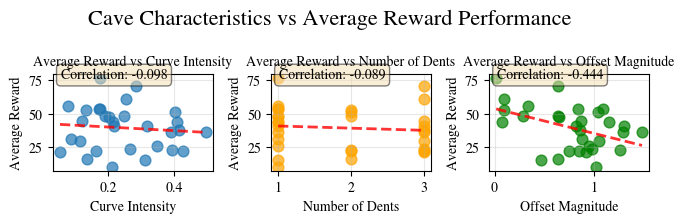


Cave Characteristics Summary:
Curve Intensity - Range: [0.054, 0.496], Mean: 0.247
Number of Dents - Range: [1, 3], Mean: 1.9
Offset Magnitude - Range: [0.016, 1.486], Mean: 0.779
Average Reward - Range: [10.728, 76.591], Mean: 39.589

Correlation Analysis:
Curve Intensity vs Reward: r=-0.0984, p=0.6049
  → Not statistically significant (p ≥ 0.05)
Number of Dents vs Reward: r=-0.0891, p=0.6396
  → Not statistically significant (p ≥ 0.05)
Offset Magnitude vs Reward: r=-0.4438, p=0.0140
  → Significant (p < 0.05)

Interpretation Guidelines:
- Effect Size: |r| < 0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)
- Statistical Significance: p < 0.05 (significant), p < 0.01 (highly significant)
- Sample Size: n = 30 caves


In [199]:
# Analyze cave characteristics vs reward performance
print("="*60)
print("CAVE CHARACTERISTICS VS REWARD ANALYSIS")
print("="*60)

# Get caves directory from session data
caves_directory = session_data.get('caves_directory', 'unknown')
print(f"Caves directory: {caves_directory}")

# Load caves_summary.json from the caves directory
caves_summary_path = os.path.join("/home/ga53voq/master_thesis", caves_directory, "caves_summary.json")
print(f"Loading cave characteristics from: {caves_summary_path}")

try:
    with open(caves_summary_path, 'r') as f:
        caves_summary = json.load(f)
    
    # Debug: Print structure of caves_summary
    print(f"Caves summary keys: {caves_summary.keys()}")
    if 'caves' in caves_summary:
        print(f"Number of caves in summary: {len(caves_summary['caves'])}")
        if caves_summary['caves']:
            print(f"Sample cave entry keys: {caves_summary['caves'][0].keys()}")
            print(f"Sample cave entry: {caves_summary['caves'][0]}")
    
    # Debug: Print evaluated cave IDs
    evaluated_cave_ids = set(cave_rewards.keys())
    print(f"Evaluated cave IDs: {sorted(evaluated_cave_ids)}")
    
    # Extract cave characteristics for the evaluated caves
    cave_characteristics = {}
    
    caves_in_summary = set()
    for cave_info in caves_summary.get('caves', []):
        cave_id = cave_info.get('id')  # Changed from 'cave_id' to 'id'
        caves_in_summary.add(cave_id)
        if cave_id in evaluated_cave_ids:
            cave_characteristics[cave_id] = {
                'curve_intensity': cave_info.get('curve_intensity', 0),
                'num_dents': cave_info.get('num_dents', 0),
                'offset_magnitude': cave_info.get('offset_magnitude', 0),
                'avg_reward': cave_stats[cave_id]['mean']
            }
    
    print(f"Cave IDs in summary: {sorted(caves_in_summary)[:10]}...{sorted(caves_in_summary)[-10:] if len(caves_in_summary) > 10 else ''}")
    print(f"Intersection of evaluated and summary cave IDs: {sorted(evaluated_cave_ids.intersection(caves_in_summary))}")
    print(f"Found characteristics for {len(cave_characteristics)} caves")
    
    # Create data lists for plotting
    curve_intensities = [cave_characteristics[cid]['curve_intensity'] for cid in cave_characteristics]
    num_dents = [cave_characteristics[cid]['num_dents'] for cid in cave_characteristics]
    offset_magnitudes = [cave_characteristics[cid]['offset_magnitude'] for cid in cave_characteristics]
    avg_rewards = [cave_characteristics[cid]['avg_reward'] for cid in cave_characteristics]

    # Graph cumulative reward for all episodes
    plt.rcParams.update({
        'font.family': 'Nimbus Roman',
        'font.size': 10,
        'axes.titlesize': 10,
        'axes.labelsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10
    })

    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(latex_linewidth_in, latex_linewidth_in/3))
    fig.suptitle('Cave Characteristics vs Average Reward Performance', fontsize=16)
    
    # Plot 1: Curve Intensity vs Reward
    axes[0].scatter(curve_intensities, avg_rewards, alpha=0.7, s=60)
    axes[0].set_xlabel('Curve Intensity')
    axes[0].set_ylabel('Average Reward')
    axes[0].set_title('Average Reward vs Curve Intensity')
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    if len(curve_intensities) > 1:
        z = np.polyfit(curve_intensities, avg_rewards, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(curve_intensities), max(curve_intensities), 100)
        axes[0].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
        correlation = np.corrcoef(curve_intensities, avg_rewards)[0,1]
        axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[0].transAxes, 
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    # Plot 2: Number of Dents vs Reward
    axes[1].scatter(num_dents, avg_rewards, alpha=0.7, s=60, color='orange')
    axes[1].set_xlabel('Number of Dents')
    axes[1].set_ylabel('Average Reward')
    axes[1].set_title('Average Reward vs Number of Dents')
    axes[1].grid(True, alpha=0.3)
    
    # Add trend line
    if len(num_dents) > 1:
        z = np.polyfit(num_dents, avg_rewards, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(num_dents), max(num_dents), 100)
        axes[1].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
        correlation = np.corrcoef(num_dents, avg_rewards)[0,1]
        axes[1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1].transAxes,
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    # Plot 3: Offset Magnitude vs Reward
    axes[2].scatter(offset_magnitudes, avg_rewards, alpha=0.7, s=60, color='green')
    axes[2].set_xlabel('Offset Magnitude')
    axes[2].set_ylabel('Average Reward')
    axes[2].set_title('Average Reward vs Offset Magnitude')
    axes[2].grid(True, alpha=0.3)
    
    # Add trend line
    if len(offset_magnitudes) > 1:
        z = np.polyfit(offset_magnitudes, avg_rewards, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(offset_magnitudes), max(offset_magnitudes), 100)
        axes[2].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
        correlation = np.corrcoef(offset_magnitudes, avg_rewards)[0,1]
        axes[2].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[2].transAxes,
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nCave Characteristics Summary:")
    print("=" * 50)
    print(f"Curve Intensity - Range: [{min(curve_intensities):.3f}, {max(curve_intensities):.3f}], Mean: {np.mean(curve_intensities):.3f}")
    print(f"Number of Dents - Range: [{min(num_dents)}, {max(num_dents)}], Mean: {np.mean(num_dents):.1f}")
    print(f"Offset Magnitude - Range: [{min(offset_magnitudes):.3f}, {max(offset_magnitudes):.3f}], Mean: {np.mean(offset_magnitudes):.3f}")
    print(f"Average Reward - Range: [{min(avg_rewards):.3f}, {max(avg_rewards):.3f}], Mean: {np.mean(avg_rewards):.3f}")
    
    print("\nCorrelation Analysis:")
    print("=" * 50)
    
    # Import scipy for statistical significance testing
    from scipy.stats import pearsonr
    
    if len(curve_intensities) > 1:
        corr_curve, p_value_curve = pearsonr(curve_intensities, avg_rewards)
        print(f"Curve Intensity vs Reward: r={corr_curve:.4f}, p={p_value_curve:.4f}")
        if p_value_curve < 0.001:
            print("  → Highly significant (p < 0.001)")
        elif p_value_curve < 0.01:
            print("  → Significant (p < 0.01)")
        elif p_value_curve < 0.05:
            print("  → Significant (p < 0.05)")
        else:
            print("  → Not statistically significant (p ≥ 0.05)")
    
    if len(num_dents) > 1:
        corr_dents, p_value_dents = pearsonr(num_dents, avg_rewards)
        print(f"Number of Dents vs Reward: r={corr_dents:.4f}, p={p_value_dents:.4f}")
        if p_value_dents < 0.001:
            print("  → Highly significant (p < 0.001)")
        elif p_value_dents < 0.01:
            print("  → Significant (p < 0.01)")
        elif p_value_dents < 0.05:
            print("  → Significant (p < 0.05)")
        else:
            print("  → Not statistically significant (p ≥ 0.05)")
    
    if len(offset_magnitudes) > 1:
        corr_offset, p_value_offset = pearsonr(offset_magnitudes, avg_rewards)
        print(f"Offset Magnitude vs Reward: r={corr_offset:.4f}, p={p_value_offset:.4f}")
        if p_value_offset < 0.001:
            print("  → Highly significant (p < 0.001)")
        elif p_value_offset < 0.01:
            print("  → Significant (p < 0.01)")
        elif p_value_offset < 0.05:
            print("  → Significant (p < 0.05)")
        else:
            print("  → Not statistically significant (p ≥ 0.05)")
    
    # Add interpretation
    print("\nInterpretation Guidelines:")
    print("- Effect Size: |r| < 0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)")
    print("- Statistical Significance: p < 0.05 (significant), p < 0.01 (highly significant)")
    print(f"- Sample Size: n = {len(avg_rewards)} caves")
    print("=" * 50)

except FileNotFoundError:
    print(f"Error: Could not find caves_summary.json at {caves_summary_path}")
    print("Make sure the caves directory path is correct.")
except Exception as e:
    print(f"Error loading cave characteristics: {e}")
    
print("="*60)

In [200]:
# Save all plots as PDF files
import matplotlib.backends.backend_pdf
from matplotlib.backends.backend_pdf import PdfPages

print("="*60)
print("SAVING PLOTS TO PDF")
print("="*60)

# Create output directory for PDFs if it doesn't exist
pdf_output_dir = Path(eval_session_path) / "analysis_plots"
pdf_output_dir.mkdir(exist_ok=True)

# 1. Recreate and save the main evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(latex_linewidth_in, 0.8 * latex_linewidth_in))
fig.suptitle('Evaluation Session Analysis', fontsize=16)

# Plot 1: Distribution of all rewards
axes[0, 0].hist(all_rewards, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
axes[0, 0].axvline(overall_mean + overall_std, color='orange', linestyle='--', alpha=0.7, label=f'+1 STD: {overall_mean + overall_std:.2f}')
axes[0, 0].axvline(overall_mean - overall_std, color='orange', linestyle='--', alpha=0.7, label=f'-1 STD: {overall_mean - overall_std:.2f}')
axes[0, 0].set_title('Distribution of All Episode Rewards')
axes[0, 0].set_xlabel('Cumulative Reward')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Cave mean rewards
cave_ids = sorted(cave_rewards.keys())
means = [cave_stats[cave_id]['mean'] for cave_id in cave_ids]
stds = [cave_stats[cave_id]['std'] for cave_id in cave_ids]

axes[0, 1].errorbar(range(len(cave_ids)), means, yerr=stds, fmt='o-', capsize=5, capthick=2)
axes[0, 1].set_title('Mean Reward per Cave (with std dev)')
axes[0, 1].set_xlabel('Cave Index')
axes[0, 1].set_ylabel('Mean Cumulative Reward')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, len(cave_ids), 5))
axes[0, 1].set_xticklabels([str(cave_ids[i]) for i in range(0, len(cave_ids), 5)])

# Plot 3: Box plot of rewards per cave (showing first 15 caves for readability)
first_15_caves = cave_ids[:15]
first_15_rewards = [cave_rewards[cave_id] for cave_id in first_15_caves]
axes[1, 0].boxplot(first_15_rewards, labels=first_15_caves)
axes[1, 0].set_title('Reward Distribution per Cave (First 15 Caves)')
axes[1, 0].set_xlabel('Cave ID')
axes[1, 0].set_ylabel('Cumulative Reward')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Standard deviation per cave
axes[1, 1].bar(range(len(cave_ids)), stds, alpha=0.7, color='lightcoral')
axes[1, 1].set_title('Standard Deviation per Cave')
axes[1, 1].set_xlabel('Cave Index')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(0, len(cave_ids), 5))
axes[1, 1].set_xticklabels([str(cave_ids[i]) for i in range(0, len(cave_ids), 5)])

plt.tight_layout()

# Save main evaluation plots
main_plots_pdf = pdf_output_dir / "evaluation_analysis_main_plots.pdf"
plt.savefig(main_plots_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"Main evaluation plots saved to: {main_plots_pdf}")
plt.close()

# 2. Recreate and save cave characteristics plots (if data exists)
if 'cave_characteristics' in locals() and len(cave_characteristics) > 0:
    # Create data lists for plotting
    curve_intensities = [cave_characteristics[cid]['curve_intensity'] for cid in cave_characteristics]
    num_dents = [cave_characteristics[cid]['num_dents'] for cid in cave_characteristics]
    offset_magnitudes = [cave_characteristics[cid]['offset_magnitude'] for cid in cave_characteristics]
    avg_rewards = [cave_characteristics[cid]['avg_reward'] for cid in cave_characteristics]
    
    fig, axes = plt.subplots(1, 3, figsize=(latex_linewidth_in, latex_linewidth_in / 3))
    fig.suptitle('Cave Characteristics vs Average Reward Performance', fontsize=16)
    
    # Plot 1: Curve Intensity vs Reward
    axes[0].scatter(curve_intensities, avg_rewards, alpha=0.7, s=60)
    axes[0].set_xlabel('Curve Intensity')
    axes[0].set_ylabel('Average Reward')
    axes[0].set_title('Average Reward vs Curve Intensity')
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    if len(curve_intensities) > 1:
        z = np.polyfit(curve_intensities, avg_rewards, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(curve_intensities), max(curve_intensities), 100)
        axes[0].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
        correlation = np.corrcoef(curve_intensities, avg_rewards)[0,1]
        axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[0].transAxes, 
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    # Plot 2: Number of Dents vs Reward
    axes[1].scatter(num_dents, avg_rewards, alpha=0.7, s=60, color='orange')
    axes[1].set_xlabel('Number of Dents')
    axes[1].set_ylabel('Average Reward')
    axes[1].set_title('Average Reward vs Number of Dents')
    axes[1].grid(True, alpha=0.3)
    
    # Add trend line
    if len(num_dents) > 1:
        z = np.polyfit(num_dents, avg_rewards, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(num_dents), max(num_dents), 100)
        axes[1].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
        correlation = np.corrcoef(num_dents, avg_rewards)[0,1]
        axes[1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1].transAxes,
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    # Plot 3: Offset Magnitude vs Reward
    axes[2].scatter(offset_magnitudes, avg_rewards, alpha=0.7, s=60, color='green')
    axes[2].set_xlabel('Offset Magnitude')
    axes[2].set_ylabel('Average Reward')
    axes[2].set_title('Average Reward vs Offset Magnitude')
    axes[2].grid(True, alpha=0.3)
    
    # Add trend line
    if len(offset_magnitudes) > 1:
        z = np.polyfit(offset_magnitudes, avg_rewards, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(offset_magnitudes), max(offset_magnitudes), 100)
        axes[2].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
        correlation = np.corrcoef(offset_magnitudes, avg_rewards)[0,1]
        axes[2].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[2].transAxes,
                    bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Save cave characteristics plots
    characteristics_plots_pdf = pdf_output_dir / "cave_characteristics_vs_reward.pdf"
    plt.savefig(characteristics_plots_pdf, format='pdf', bbox_inches='tight', dpi=300)
    print(f"Cave characteristics plots saved to: {characteristics_plots_pdf}")
    plt.close()

print(f"\nAll plots saved to directory: {pdf_output_dir}")
print("Files created:")
for pdf_file in pdf_output_dir.glob("*.pdf"):
    print(f"  - {pdf_file.name}")

print("="*60)

SAVING PLOTS TO PDF


/tmp/ipykernel_1412246/3337902238.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(first_15_rewards, labels=first_15_caves)


Main evaluation plots saved to: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539/analysis_plots/evaluation_analysis_main_plots.pdf
Cave characteristics plots saved to: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539/analysis_plots/cave_characteristics_vs_reward.pdf

All plots saved to directory: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539/analysis_plots
Files created:
  - evaluation_analysis_main_plots.pdf
  - cave_characteristics_vs_reward.pdf
  - cumulative_reward_all_episodes.pdf
Cave characteristics plots saved to: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539/analysis_plots/cave_characteristics_vs_reward.pdf

All plots saved to directory: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539/analysis_plots
Files crea

Cumulative reward plot saved to: /home/ga53voq/master_thesis/logs/curriculum_final-2025-09-09_12-41-01/C6_eval_session_20250911_145539/analysis_plots/cumulative_reward_all_episodes.pdf


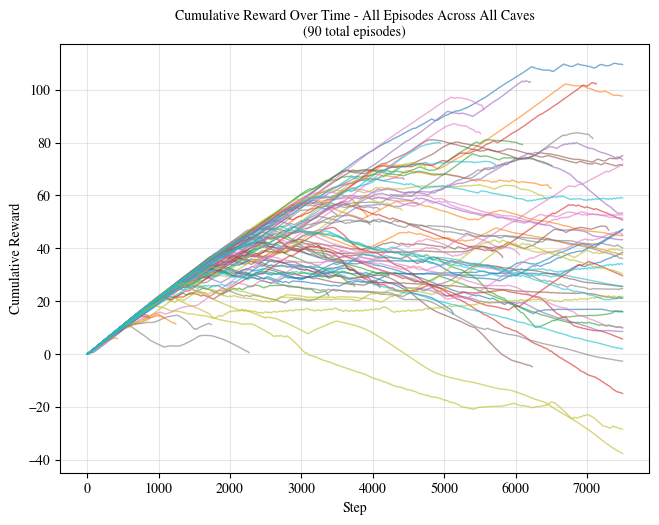


Episode Statistics:
Total episodes: 90
Final reward - Mean: 39.589, Std: 28.167
Final reward - Min: -37.625, Max: 109.481
Episode length - Mean: 5594.7, Max: 7500


In [201]:
# Graph cumulative reward for all episodes
plt.rcParams.update({
    'font.family': 'Nimbus Roman',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

plt.figure(figsize=(latex_linewidth_in, 0.8 * latex_linewidth_in))

# Collect all episode data
all_episode_data = []
cave_colors = plt.cm.tab10(np.linspace(0, 1, len(session_data['caves'])))

for cave_idx, cave_data in enumerate(session_data['caves']):
    cave_id = cave_data['cave_id']
    cave_dir = os.path.join(eval_session_path, cave_data['dir'])
    
    for episode in cave_data['episodes']:
        episode_file = os.path.join(cave_dir, episode['log_file'])
        if os.path.exists(episode_file):
            with open(episode_file, 'r') as f:
                episode_data = json.load(f)
            
            # Extract cumulative rewards and step numbers
            steps = []
            cumulative_rewards = []
            for step_data in episode_data['steps']:
                steps.append(step_data['step'])
                cumulative_rewards.append(step_data['cumulative_reward'])
            
            # Plot this episode (removed legend label)
            plt.plot(steps, cumulative_rewards, 
                    color=cave_colors[cave_idx], 
                    alpha=0.6, 
                    linewidth=1)
            
            # Store for statistics
            all_episode_data.append({
                'cave_id': cave_id,
                'episode_idx': episode['episode_index'],
                'steps': steps,
                'cumulative_rewards': cumulative_rewards,
                'final_reward': cumulative_rewards[-1] if cumulative_rewards else 0
            })

plt.xlabel('Step')
plt.ylabel('Cumulative Reward')
plt.title(f'Cumulative Reward Over Time - All Episodes Across All Caves\n({len(all_episode_data)} total episodes)')
plt.grid(True, alpha=0.3)
# Removed legend since it's not informative with so many caves
plt.tight_layout()

# Save plot as PDF
if 'pdf_output_dir' in locals():
    cumulative_reward_pdf = pdf_output_dir / "cumulative_reward_all_episodes.pdf"
else:
    pdf_output_dir = Path(eval_session_path) / "analysis_plots"
    pdf_output_dir.mkdir(exist_ok=True)
    cumulative_reward_pdf = pdf_output_dir / "cumulative_reward_all_episodes.pdf"

plt.savefig(cumulative_reward_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"Cumulative reward plot saved to: {cumulative_reward_pdf}")

plt.show()

# Print some statistics
if all_episode_data:
    final_rewards = [ep['final_reward'] for ep in all_episode_data]
    print(f"\nEpisode Statistics:")
    print(f"Total episodes: {len(all_episode_data)}")
    print(f"Final reward - Mean: {np.mean(final_rewards):.3f}, Std: {np.std(final_rewards):.3f}")
    print(f"Final reward - Min: {np.min(final_rewards):.3f}, Max: {np.max(final_rewards):.3f}")
    
    # Find longest episodes
    episode_lengths = [len(ep['steps']) for ep in all_episode_data]
    print(f"Episode length - Mean: {np.mean(episode_lengths):.1f}, Max: {np.max(episode_lengths)}")

In [202]:
import matplotlib.font_manager as fm
for f in fm.findSystemFonts():
    if "Times" in f or "Nimbus" in f:
        print(f)

/usr/share/fonts/opentype/urw-base35/NimbusRoman-Italic.otf
/usr/share/fonts/opentype/urw-base35/NimbusSansNarrow-BoldOblique.otf
/usr/share/fonts/opentype/urw-base35/NimbusMonoPS-Bold.otf
/usr/share/fonts/opentype/urw-base35/NimbusRoman-Regular.otf
/usr/share/fonts/opentype/urw-base35/NimbusSans-Italic.otf
/usr/share/fonts/opentype/urw-base35/NimbusSans-Bold.otf
/usr/share/fonts/opentype/urw-base35/NimbusSansNarrow-Bold.otf
/usr/share/fonts/opentype/urw-base35/NimbusSansNarrow-Regular.otf
/usr/share/fonts/opentype/urw-base35/NimbusSansNarrow-Oblique.otf
/usr/share/fonts/opentype/urw-base35/NimbusRoman-BoldItalic.otf
/usr/share/fonts/opentype/urw-base35/NimbusSans-Regular.otf
/usr/share/fonts/opentype/urw-base35/NimbusMonoPS-Italic.otf
/usr/share/fonts/opentype/urw-base35/NimbusMonoPS-Regular.otf
/usr/share/fonts/opentype/urw-base35/NimbusRoman-Bold.otf
/usr/share/fonts/opentype/urw-base35/NimbusMonoPS-BoldItalic.otf
/usr/share/fonts/opentype/urw-base35/NimbusSans-BoldItalic.otf
